<a href="https://colab.research.google.com/github/umraodeepika7-dotcom/ctgan/blob/main/SDV_Synthesize_a_table_(CTGAN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[SDV Docs](https://docs.sdv.dev/sdv) > [Tutorials](https://docs.sdv.dev/sdv/tutorials)

# Synthesize a Table (CTGAN)

In this notebook, we'll use the SDV to create synthetic data for a single table and evaluate it. The SDV uses machine learning to learn patterns from real data and emulates them when creating synthetic data.

We'll use the **CTGAN** algorithm to do this. CTGAN uses generative adversarial networks (GANs) to create synthesize data with high fidelity.

_Last Edit: January 30, 2026_

# 0. Installation

Install SDV Community.

In [1]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.8/204.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.9 MB/s eta 0:00:00


In [1]:
!pip install table_evaluator

In [1]:
!pip install dython

# 1. Loading the demo data
For this demo, we'll use a fake dataset that describes some fictional guests staying at a hotel.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving RS pretreatment.csv to RS pretreatment.csv


In [3]:
import pandas as pd
data = pd.read_csv('RS pretreatment.csv')

In [5]:
real_data = pd.read_csv('RS pretreatment.csv')

In [6]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=real_data)

In [7]:
display(real_data.head())

,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,H2O,Original,0.60,0.61,1.00,1.25,3.17,0.00,0.88,31.67
1,H2O,Treated,0.68,0.58,0.94,1.07,2.66,0.00,0.92,22.24
2,H2SO4,Original,10.81,2.55,3.81,1.63,36.70,2.49,7.65,69.84
3,H2SO4,Treated,10.70,1.89,4.09,1.72,31.10,0.00,1.31,44.40
4,HCl,Original,37.26,0.66,5.97,11.18,66.37,4.55,5.46,74.64


In [8]:
categorical_features = ['Catalyst', 'samples']

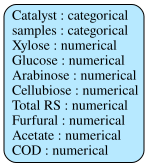

In [9]:
metadata.visualize()

In [10]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata, # required
    enforce_min_max_values=True,
    epochs=500,
    verbose=True
)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


# 2. Basic Usage

## 2.1 Creating a Synthesizer

An SDV **synthesizer** is an object that you can use to create synthetic data. It learns patterns from the real data and replicates them to generate synthetic data.

In [20]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(metadata)
synthesizer.fit(data)

synthetic_data = synthesizer.sample(num_rows=10)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [22]:
from sdv.single_table import CTGANSynthesizer

synthesizer = CTGANSynthesizer(
    metadata, # required
    enforce_min_max_values=True,
    epochs=500,
    verbose=True
)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


<font color="maroon"><i><b>This step takes a few minutes.</b> For larger datasets, this phase may take longer. A drawback of a GAN-based model like CTGAN is performance.</i></font>

When this code finishes running, the synthesizer is ready to use.

## 2.2 Generating Synthetic Data
Use the `sample` function and pass in any number of rows to synthesize.

In [23]:
synthesizer.fit(real_data)
synthetic_data = synthesizer.sample(num_rows=500)
synthetic_data.head()

Gen. (-00.78) | Discrim. (+00.05): 100%|██████████| 500/500 [00:28<00:00, 17.83it/s]


,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,H2O,Treated,24.79,2.55,1.96,9.98,2.66,0.79,2.32,29.07
1,H2SO4,Treated,16.58,0.33,6.33,1.07,30.25,0.00,0.27,22.24
2,HNO3,Original,9.24,1.38,3.30,1.33,2.68,1.14,3.66,71.08
3,H2O,Treated,12.70,0.33,0.94,1.07,60.09,0.00,0.27,22.24
4,H2O,Original,3.46,0.50,6.30,3.85,7.00,0.29,1.56,24.72


### Enforcing Group-wise Min/Max Values
To ensure that the synthetic data adheres to the min/max values observed for each `Catalyst` in the real data, we need to perform a post-processing step. First, we'll calculate the min and max for each numerical column, grouped by `Catalyst`, from the `real_data`. Then, we'll apply these bounds to the `synthetic_data`.

In [24]:
numeric_cols = ['Xylose', 'Glucose', 'Arabinose', 'Cellubiose', 'Total RS', 'Furfural', 'Acetate', 'COD']

# Calculate group-wise min/max from real_data
group_min_max = real_data.groupby('Catalyst')[numeric_cols].agg(['min', 'max'])

# Define a function to enforce group-wise min/max
def enforce_group_min_max_for_row(row, group_min_max_df, group_col, numeric_columns):
    catalyst_group = row[group_col]
    if catalyst_group in group_min_max_df.index:
        for col in numeric_columns:
            min_val = group_min_max_df.loc[catalyst_group, (col, 'min')]
            max_val = group_min_max_df.loc[catalyst_group, (col, 'max')]
            row[col] = max(min_val, min(max_val, row[col]))
    return row

# Create a copy to store the enforced synthetic data
synthetic_data_enforced = synthetic_data.copy()

# Apply the enforcement function to each row of the synthetic data
synthetic_data_enforced = synthetic_data_enforced.apply(lambda row: enforce_group_min_max_for_row(row, group_min_max, 'Catalyst', numeric_cols), axis=1)

print("Synthetic data after enforcing group-wise min/max values:")
display(synthetic_data_enforced.head())

Synthetic data after enforcing group-wise min/max values:


,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,H2O,Treated,0.68,0.61,1.00,1.25,2.66,0.00,0.92,29.07
1,H2SO4,Treated,10.81,1.89,4.09,1.63,31.10,0.00,1.31,44.40
2,HNO3,Original,30.22,2.06,6.23,9.65,61.60,1.14,3.25,71.08
3,H2O,Treated,0.68,0.58,0.94,1.07,3.17,0.00,0.88,22.24
4,H2O,Original,0.68,0.58,1.00,1.25,3.17,0.00,0.92,24.72


In [25]:
display(synthetic_data_enforced.head(500))

,Catalyst,samples,Xylose,Glucose,Arabinose,Cellubiose,Total RS,Furfural,Acetate,COD
0,H2O,Treated,0.68,0.61,1.00,1.25,2.66,0.00,0.92,29.07
1,H2SO4,Treated,10.81,1.89,4.09,1.63,31.10,0.00,1.31,44.40
2,HNO3,Original,30.22,2.06,6.23,9.65,61.60,1.14,3.25,71.08
3,H2O,Treated,0.68,0.58,0.94,1.07,3.17,0.00,0.88,22.24
4,H2O,Original,0.68,0.58,1.00,1.25,3.17,0.00,0.92,24.72
...,...,...,...,...,...,...,...,...,...,...
495,H2O,Treated,0.60,0.58,1.00,1.07,3.17,0.00,0.92,31.67
496,HNO3,Original,30.22,2.06,6.23,9.65,63.40,1.34,3.25,64.50
497,H2O,Treated,0.68,0.61,1.00,1.25,2.66,0.00,0.88,31.67
498,H2SO4,Original,10.81,1.89,3.81,1.63,36.70,2.26,7.65,63.18


### Comparing Distributions of Real vs. Enforced Synthetic Data

Now, let's visualize the 1D distributions of each numerical column to compare the `real_data` with the `synthetic_data_enforced` after applying group-wise min/max constraints.

In [27]:
from sdv.evaluation.single_table import get_column_plot
import matplotlib.pyplot as plt

# numeric_cols is already defined from previous steps
# numeric_cols = ['Xylose', 'Glucose', 'Arabinose', 'Cellubiose', 'Total RS', 'Furfural', 'Acetate', 'COD']

for col_name in numeric_cols:
    print(f"Plotting distribution for column: {col_name}")
    fig = get_column_plot(
        real_data=real_data,
        synthetic_data=synthetic_data_enforced,
        column_name=col_name,
        metadata=metadata
    )
    # Save the figure to a file instead of showing it directly
    fig.savefig(f'{col_name}_distribution_comparison.png')
    plt.close(fig) # Close the figure to free up memory

Plotting distribution for column: Xylose


AttributeError: 'Figure' object has no attribute 'savefig'

In [28]:
# Install kaleido for plotly image export
%pip install kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 744.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.0 MB/s eta 0:00:00


In [29]:
from sdv.evaluation.single_table import get_column_plot

# numeric_cols is already defined from previous steps
# numeric_cols = ['Xylose', 'Glucose', 'Arabinose', 'Cellubiose', 'Total RS', 'Furfural', 'Acetate', 'COD']

for col_name in numeric_cols:
    print(f"Plotting distribution for column: {col_name}")
    fig = get_column_plot(
        real_data=real_data,
        synthetic_data=synthetic_data_enforced,
        column_name=col_name,
        metadata=metadata
    )
    # Save the figure to a file using Plotly's write_image method
    fig.write_image(f'{col_name}_distribution_comparison.png')

Plotting distribution for column: Xylose


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


The synthesizer is generating synthetic guests in the **same format as the original data**.

### Quality Report Summary
Let's summarize the overall quality score from the previously generated report and also look into the details of 'Column Pair Trends'.

In [18]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)
print(f"Overall Quality Score (Average): {quality_report.get_score():.2f}%")
quality_report.get_details('Column Pair Trends')

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 10/10 [00:00<00:00, 588.49it/s]|
Column Shapes Score: 70.58%

(2/2) Evaluating Column Pair Trends: |██████████| 45/45 [00:00<00:00, 130.86it/s]|
Column Pair Trends Score: 52.55%

Overall Score (Average): 61.57%

Overall Quality Score (Average): 0.62%


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,Catalyst,samples,ContingencySimilarity,NaN,NaN,NaN,0.000000,False
1,Catalyst,Xylose,ContingencySimilarity,0.200000,NaN,NaN,1.000000,True
2,Catalyst,Glucose,ContingencySimilarity,0.212000,NaN,NaN,0.781736,True
3,Catalyst,Arabinose,ContingencySimilarity,0.266000,NaN,NaN,0.912871,True
4,Catalyst,Cellubiose,ContingencySimilarity,0.320000,NaN,NaN,0.707107,True
5,Catalyst,Total RS,ContingencySimilarity,0.200000,NaN,NaN,0.881917,True
6,Catalyst,Furfural,ContingencySimilarity,0.496000,NaN,NaN,0.632456,True
7,Catalyst,Acetate,ContingencySimilarity,0.184000,NaN,NaN,0.881917,True
8,Catalyst,COD,ContingencySimilarity,0.321000,NaN,NaN,0.912871,True
9,samples,Xylose,ContingencySimilarity,0.463000,NaN,NaN,0.500000,True


## 2.3 Evaluating Real vs. Synthetic Data

SDV has built-in functions for evaluating the synthetic data and getting more insight.

As a first step, we can run a **diagnostic** to ensure that the data is valid. SDV's diagnostic performs some basic checks such as:

- All primary keys must be unique
- Continuous values must adhere to the min/max of the real data
- Discrete columns (non-PII) must have the same categories as the real data
- Etc.

In [19]:
from sdv.evaluation.single_table import run_diagnostic

diagnostic = run_diagnostic(
    real_data=real_data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 10/10 [00:00<00:00, 711.60it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 132.71it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



<font color="green"><b>The score is 100%</b></font>, indicating that the data is fully valid.

We can also measure the **data quality** or the statistical similarity between the real and synthetic data. This value may vary anywhere from 0 to 100%.

In [ ]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data,
    synthetic_data,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 505.30it/s]|
Column Shapes Score: 77.03%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 459.98it/s]|
Column Pair Trends Score: 55.98%

Overall Score (Average): 66.51%



The score tells us how similar the synthetic data is to the real data in terms of statistical patterns.

We can also get more details from the report. For example, the Column Shapes sub-score: Which columns had the highest vs. the lowest scores?

In [ ]:
quality_report.get_details('Column Shapes')

,Column,Metric,Score
0,has_rewards,TVComplement,0.838000
1,room_type,TVComplement,0.786000
2,amenities_fee,KSComplement,0.675698
3,checkin_date,KSComplement,0.832000
4,checkout_date,KSComplement,0.858333
5,room_rate,KSComplement,0.632000


## 2.4 Visualizing the Data
For more insights, we can visualize the real vs. synthetic data.

Let's perform a 1D visualization comparing a column of the real data to the synthetic data.

In [ ]:
from sdv.evaluation.single_table import get_column_plot

fig = get_column_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_name='room_type',
    metadata=metadata
)

fig.show()

We can also visualize in 2D, comparing the correlations of a pair of columns.

In [ ]:
from sdv.evaluation.single_table import get_column_pair_plot

fig = get_column_pair_plot(
    real_data=real_data,
    synthetic_data=synthetic_data,
    column_names=['room_rate', 'room_type'],
    metadata=metadata
)

fig.show()

## 2.5 Anonymization

In the original dataset, we had some sensitive columns such as the guest's email, billing address and phone number. In the synthetic data, these columns are **fully anonymized** -- they contain entirely fake values that follow the format of the original.

PII columns are not included in the quality report, but we can inspect them to see that they are different.

In [ ]:
sensitive_column_names = ['guest_email', 'billing_address', 'credit_card_number']

real_data[sensitive_column_names].head(3)

,guest_email,billing_address,credit_card_number
0,michaelsanders@shaw.net,"49380 Rivers Street\nSpencerville, AK 68265",4075084747483975747
1,randy49@brown.biz,"88394 Boyle Meadows\nConleyberg, TN 22063",180072822063468
2,webermelissa@neal.com,"0323 Lisa Station Apt. 208\nPort Thomas, LA 82585",38983476971380


In [ ]:
synthetic_data[sensitive_column_names].head(3)

,guest_email,billing_address,credit_card_number
0,dsullivan@example.net,"90469 Karla Knolls Apt. 781\nSusanberg, CA 70033",5161033759518983
1,steven59@example.org,"6108 Carla Ports Apt. 116\nPort Evan, MI 71694",4133047413145475690
2,brandon15@example.net,86709 Jeremy Manors Apt. 786\nPort Garychester...,4977328103788


## 2.6 Saving and Loading
We can save the synthesizer to share with others and sample more synthetic data in the future.

In [ ]:
synthesizer.save('my_synthesizer.pkl')

In [ ]:
from sdv.utils import load_synthesizer

synthesizer = load_synthesizer('my_synthesizer.pkl')
synthesizer.sample(num_rows=3)

,guest_email,has_rewards,room_type,amenities_fee,checkin_date,checkout_date,room_rate,billing_address,credit_card_number
0,cburns@example.com,False,BASIC,NaN,07 Jan 2021,29 Feb 2020,131.16,Unit 7909 Box 7283\nDPO AA 48458,30158284644887
1,jordanpamela@example.org,False,BASIC,12.15,26 Oct 2020,30 Sep 2020,133.41,"0837 Stewart Pike Suite 951\nPort Zachary, IA ...",4375705762878737
2,amanda33@example.org,False,BASIC,10.98,18 Jul 2020,07 Jan 2020,424.84,"24644 Pollard Burgs Apt. 192\nSarahview, PA 78396",180027361090256


# 3. CTGAN Customization
When using this synthesizer, we can make a tradeoff between training time and data quality using the `epochs` parameter: Higher `epochs` means that the synthesizer will train for longer, and ideally improve the data quality.

To see the progress, we can also turn on the `verbose` parameter. This will show a progress bar that will fill up as the synthesizer completes the fit process.


In [ ]:
custom_synthesizer = CTGANSynthesizer(
    metadata,
    epochs=1000,
    verbose=True)
custom_synthesizer.fit(real_data)

Gen. (-0.93) | Discrim. (-0.21): 100%|██████████| 1000/1000 [01:03<00:00, 15.86it/s]


<font color="maroon"><i><b>This code takes longer to run.</b></i></font>

After we've trained our synthesizer, we can verify the changes to the data quality by creating some synthetic data and evaluating it.

In [ ]:
synthetic_data_customized = custom_synthesizer.sample(num_rows=500)

quality_report = evaluate_quality(
    real_data,
    synthetic_data_customized,
    metadata
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 574.60it/s]|
Column Shapes Score: 82.86%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 412.45it/s]|
Column Pair Trends Score: 72.36%

Overall Score (Average): 77.61%



While GANs are able to model complex patterns and shapes, it is not easy to understand how they are learning -- but it is possible to modify the underlying architecture of the neural networks.

For users who are familiar with the GAN architecture, there are extra parameters you can use to tune CTGAN to your particular needs. For more details, see [the CTGAN documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer).

# 4. What's Next?

For more information about the CTGAN Synthesizer, visit the **[documentation](https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer)**.

⭐ To learn about other SDV features, [browse all tutorials](https://docs.sdv.dev/sdv/demos)

⭐ **Need more help?** [Visit our forum](https://forum.datacebo.com/) for troubleshooting, questions, or general feedback.

---

# About

The [Synthetic Data Vault Project](https://github.com/sdv-dev/SDV) was first created at MIT's Data to AI Lab in 2016. After 4 years of research and traction with enterprise, we created [DataCebo](https://datacebo.com/) in 2020 with the goal of growing the project. Today, DataCebo is the proud developer of SDV, the largest ecosystem for tabular synthetic data generation & evaluation.

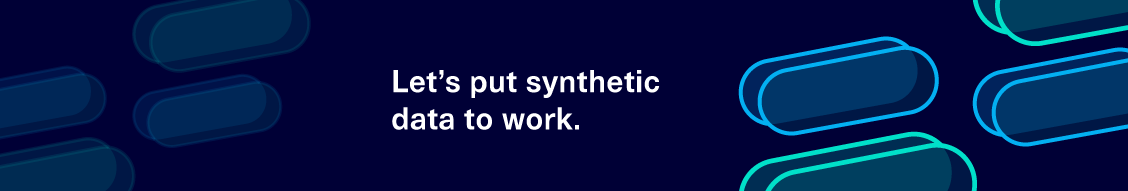